In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import torch.optim as optim
import torch,time
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import json
import torchvision
from torchvision.utils import save_image, make_grid
from torch.utils.data import Subset, random_split
from glob import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import pandas as pd
import shutil
from pycocotools import mask as coco_mask
import os
from glob import glob
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import timm

In [ ]:
!pip install  grad-cam

In [2]:
!git clone https://github.com/jasonfghx/retina_image.git


Cloning into 'retina_image'...
remote: Enumerating objects: 3731, done.
remote: Counting objects: 100% (337/337), done.
remote: Compressing objects: 100% (325/325), done.
remote: Total 3731 (delta 34), reused 11 (delta 11), pack-reused 3394 (from 3)
Receiving objects: 100% (3731/3731), 477.87 MiB | 30.11 MiB/s, done.
Resolving deltas: 100% (239/239), done.
Updating files: 100% (3271/3271), done.


In [14]:
# resnet
import os
import torch
from torch import nn, optim

from sklearn.model_selection import train_test_split
from PIL import Image
use_amp = torch.cuda.is_available()
# 設定 GPU 或 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 圖像轉換：將圖片調整為合適的大小並進行正規化
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),              # 轉換為Tensor格式
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
image_dir = '/content/retina_image/OCT'

full_dataset = datasets.ImageFolder(root=image_dir, transform=transform)

train_dataset, val_dataset = train_test_split(full_dataset, test_size=0.2, random_state=42)

In [4]:
num_classes=8
class MultiScaleCNNExtractor(nn.Module):
    """
    Multi-Scale CNN Extractor fusing ResNet-50 Layer 3 (1024-dim, 14x14) and Layer 4 (2048-dim, 7x7).
    Produces unified 384-dimensional feature map with 14x14 grid (196 visual tokens).
    """
    def __init__(self, out_dim=384):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3  # [B, 1024, 14, 14]
        self.layer4 = resnet.layer4  # [B, 2048, 7, 7]
        self.resnet_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.proj_l4 = nn.Sequential(
            nn.Conv2d(2048, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True)
        )
        self.proj_l3 = nn.Sequential(
            nn.Conv2d(1024, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True)
        )
        self.fuse_conv = nn.Sequential(
            nn.Conv2d(out_dim * 2, out_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        B = x.size(0)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        feat_l3 = self.layer3(x)   # [B, 1024, 14, 14]
        feat_l4 = self.layer4(feat_l3) # [B, 2048, 7, 7]

        res_global = self.resnet_pool(feat_l4).view(B, -1) # [B, 2048]

        p4 = self.proj_l4(feat_l4)
        p4_up = F.interpolate(p4, size=(14, 14), mode='bilinear', align_corners=False)
        p3 = self.proj_l3(feat_l3)
        fused_map = self.fuse_conv(torch.cat([p3, p4_up], dim=1)) # [B, 384, 14, 14]
        cnn_tokens = fused_map.flatten(2).transpose(1, 2) # [B, 196, 384]
        return cnn_tokens, res_global, feat_l4


class LocalCrossAttention(nn.Module):
    def __init__(self, dim=384, num_heads=6):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, cnn_tokens, vit_patches):
        # cnn_tokens: [B, 196, 384], vit_patches: [B, 196, 384]
        attn_out, _ = self.cross_attn(query=cnn_tokens, key=vit_patches, value=vit_patches, need_weights=False)
        return self.norm(attn_out + cnn_tokens).mean(dim=1) # [B, 384]


class ResNet50ViTSmall_GatedFusion(nn.Module):
    """
    Proposed v3 Architecture: ResNet-50 + ViT-Small/16 Multi-Scale LCA & Gated Fusion (~46.5M Parameters).
    """
    def __init__(self, num_classes=8, fusion_dim=512):
        super().__init__()
        self.cnn_extractor = MultiScaleCNNExtractor(out_dim=384)

        # ViT-Small/16 (21.7M parameters, 384 embed dim, 6 heads, 12 layers)
        self.vit_backbone = timm.create_model('vit_small_patch16_224', pretrained=True, drop_rate=0.0, drop_path_rate=0.0)

        self.local_cross_attn = LocalCrossAttention(dim=384, num_heads=6)
        self.res_proj   = nn.Linear(2048, fusion_dim)
        self.vit_proj   = nn.Linear(384, fusion_dim)
        self.cross_proj = nn.Linear(384, fusion_dim)

        self.fusion_gate = nn.Sequential(
            nn.Linear(fusion_dim * 3, 256),
            nn.LayerNorm(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        B = x.size(0)
        # 1. Multi-Scale CNN Branch
        cnn_tokens, res_global, _ = self.cnn_extractor(x)

        # 2. ViT-Small Branch
        vit_features = self.vit_backbone.forward_features(x)
        if hasattr(self.vit_backbone, 'num_prefix_tokens') and self.vit_backbone.num_prefix_tokens > 0:
            vit_cls = vit_features[:, 0]
            vit_patches = vit_features[:, self.vit_backbone.num_prefix_tokens:, :]
        else:
            vit_cls = vit_features[:, 0]
            vit_patches = vit_features[:, 1:, :]

        # 3. Projections & LCA
        h_res   = self.res_proj(res_global)
        h_vit   = self.vit_proj(vit_cls)
        h_cross = self.cross_proj(self.local_cross_attn(cnn_tokens, vit_patches))

        # 4. Gated Convex Fusion
        w = self.fusion_gate(torch.cat([h_res, h_vit, h_cross], dim=1))
        fused = w[:, 0:1] * h_res + w[:, 1:2] * h_vit + w[:, 2:3] * h_cross
        return self.classifier(fused), fused

model = ResNet50ViTSmall_GatedFusion(num_classes=num_classes).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

In [10]:


# 4. 創建DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
epochs = 20
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()
for epoch in range(epochs):

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # 注意：你的 model 回傳兩個東西
        outputs, fused = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

    # =========================
    # Validation
    # =========================
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs, fused = model(inputs)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(
        f"Validation Loss: {val_loss:.4f} "
        f"Validation Acc: {val_acc:.2f}%"
    )

Epoch [1/20] Train Loss: 0.9962 Train Acc: 67.71%
Validation Loss: 0.3888 Validation Acc: 87.23%
Epoch [2/20] Train Loss: 0.2702 Train Acc: 91.26%
Validation Loss: 0.2125 Validation Acc: 92.21%
Epoch [3/20] Train Loss: 0.0716 Train Acc: 98.67%
Validation Loss: 0.2343 Validation Acc: 94.08%
Epoch [4/20] Train Loss: 0.0172 Train Acc: 99.84%
Validation Loss: 0.2045 Validation Acc: 93.77%
Epoch [5/20] Train Loss: 0.0244 Train Acc: 99.14%
Validation Loss: 0.1962 Validation Acc: 94.70%
Epoch [6/20] Train Loss: 0.0208 Train Acc: 99.30%
Validation Loss: 0.2311 Validation Acc: 94.08%
Epoch [7/20] Train Loss: 0.0159 Train Acc: 99.53%
Validation Loss: 0.2425 Validation Acc: 92.83%
Epoch [8/20] Train Loss: 0.0796 Train Acc: 97.50%
Validation Loss: 0.2989 Validation Acc: 89.72%
Epoch [9/20] Train Loss: 0.0437 Train Acc: 98.99%
Validation Loss: 0.2898 Validation Acc: 92.83%
Epoch [10/20] Train Loss: 0.0554 Train Acc: 98.52%
Validation Loss: 0.3179 Validation Acc: 91.59%
Epoch [11/20] Train Loss: 0.0

In [ ]:
# model
# torch.save(model, "/content/best_model.pth")
# Save weights
torch.save(model.state_dict(), "model_weights.pth")

In [ ]:
print(full_dataset.class_to_idx.keys())


dict_keys(['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL'])


In [ ]:
import torch

model.eval()  # 設定模型為 evaluation 模式
all_preds = []
all_labels = []

with torch.no_grad():  # 禁用梯度計算，節省記憶體和加速
    for batch in val_loader:
        inputs, labels = batch  # 根據你的 val_dataset 的設計，可能是 (inputs,) 或 (inputs, labels)
        inputs = inputs.to(device)  # 如果你有用 GPU
        labels = labels.to(device)

        outputs = model(inputs)  # 前向傳播
        preds = torch.argmax(outputs, dim=1)  # 假設是分類問題

        all_preds.extend(preds.cpu().numpy())  # 儲存預測結果
        all_labels.extend(labels.cpu().numpy())  # 儲存真實標籤（可選）

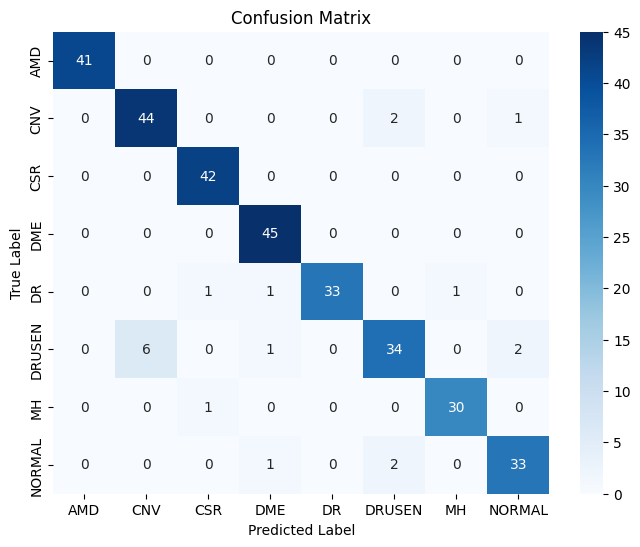

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.94      0.88      0.91        50
           2       1.00      0.95      0.98        44
           3       1.00      0.94      0.97        48
           4       0.92      1.00      0.96        33
           5       0.79      0.89      0.84        38
           6       0.97      0.97      0.97        31
           7       0.92      0.92      0.92        36

    accuracy                           0.94       321
   macro avg       0.94      0.94      0.94       321
weighted avg       0.94      0.94      0.94       321



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 計算 confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 如果你有類別名稱（可選）
class_names = list(full_dataset.class_to_idx.keys())

# 繪圖
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(all_preds, all_labels))

In [ ]:
ClassifierOutputTarget

pytorch_grad_cam.utils.model_targets.ClassifierOutputTarget

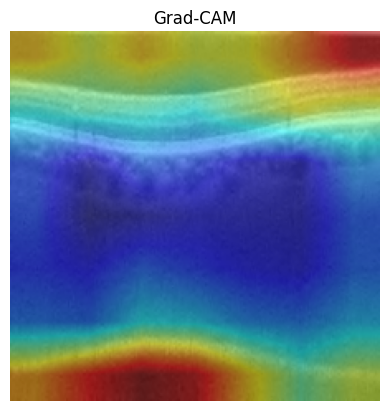

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_path = '/content/retina_image/OCT/AMD/amd_train_1001.jpg'
img = Image.open(img_path).convert('RGB')
img = img.resize((224, 224))

# 預處理輸入影像
input_tensor = transform(img).unsqueeze(0).to(device)

targets = [ClassifierOutputTarget(1)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# 疊加在圖上
img_float = np.array(img).astype(np.float32) / 255.0
visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

plt.imshow(visualization[:,:,:])
plt.axis('off')
plt.title('Grad-CAM')
plt.show()

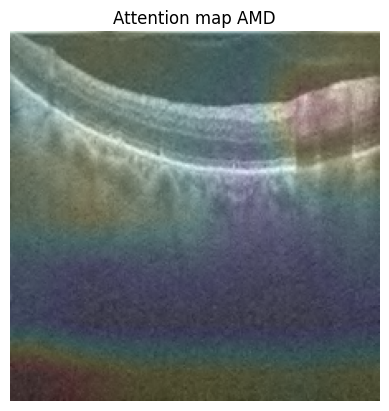

In [ ]:
img_path = '/content/retina_image/OCT/AMD/amd_train_1007.jpg'
img = Image.open(img_path).convert('RGB')
img = img.resize((224, 224))

# 預處理輸入影像
input_tensor = transform(img).unsqueeze(0).to(device)

targets = [ClassifierOutputTarget(1)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# 疊加在圖上
img_float = np.array(img).astype(np.float32) / 255.0
visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True,image_weight=0.9)

plt.imshow(visualization[:,:,:])
plt.axis('off')
plt.title('Attention map AMD')
plt.show()


In [ ]:
image = Image.open("/content/retina_image/OCT/MH/mh_train_1075.jpg")

image_tensor = transform(image).unsqueeze(0)

model.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),2)*100))

預測類別: MH  機率: 98.0


In [ ]:
add=glob("/content/retina_image/OCT/DRUSEN/*")
for i in add:
  image = Image.open(i).convert("RGB")

  image_tensor = transform(image).unsqueeze(0)

  model.eval()
  image_tensor = image_tensor.to(device)
  with torch.no_grad():
      output, fused = model(image_tensor)

      predicted_class = torch.argmax(
        output, dim=1
    ).item()
  class_names={v : k for k,v in full_dataset.class_to_idx.items()}
  probabilities = torch.softmax(output, dim=1)
  print(i,"預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),4)*100))

In [ ]:
num_classes=8
class MultiScaleCNNExtractor(nn.Module):
    """
    Multi-Scale CNN Extractor fusing ResNet-50 Layer 3 (1024-dim, 14x14) and Layer 4 (2048-dim, 7x7).
    Produces unified 384-dimensional feature map with 14x14 grid (196 visual tokens).
    """
    def __init__(self, out_dim=384):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3  # [B, 1024, 14, 14]
        self.layer4 = resnet.layer4  # [B, 2048, 7, 7]
        self.resnet_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.proj_l4 = nn.Sequential(
            nn.Conv2d(2048, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True)
        )
        self.proj_l3 = nn.Sequential(
            nn.Conv2d(1024, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True)
        )
        self.fuse_conv = nn.Sequential(
            nn.Conv2d(out_dim * 2, out_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        B = x.size(0)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        feat_l3 = self.layer3(x)   # [B, 1024, 14, 14]
        feat_l4 = self.layer4(feat_l3) # [B, 2048, 7, 7]

        res_global = self.resnet_pool(feat_l4).view(B, -1) # [B, 2048]

        p4 = self.proj_l4(feat_l4)
        p4_up = F.interpolate(p4, size=(14, 14), mode='bilinear', align_corners=False)
        p3 = self.proj_l3(feat_l3)
        fused_map = self.fuse_conv(torch.cat([p3, p4_up], dim=1)) # [B, 384, 14, 14]
        cnn_tokens = fused_map.flatten(2).transpose(1, 2) # [B, 196, 384]
        return cnn_tokens, res_global, feat_l4


class LocalCrossAttention(nn.Module):
    def __init__(self, dim=384, num_heads=6):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, cnn_tokens, vit_patches):
        # cnn_tokens: [B, 196, 384], vit_patches: [B, 196, 384]
        attn_out, _ = self.cross_attn(query=cnn_tokens, key=vit_patches, value=vit_patches, need_weights=False)
        return self.norm(attn_out + cnn_tokens).mean(dim=1) # [B, 384]


class ResNet50ViTSmall_GatedFusion(nn.Module):
    """
    Proposed v3 Architecture: ResNet-50 + ViT-Small/16 Multi-Scale LCA & Gated Fusion (~46.5M Parameters).
    """
    def __init__(self, num_classes=8, fusion_dim=512):
        super().__init__()
        self.cnn_extractor = MultiScaleCNNExtractor(out_dim=384)

        # ViT-Small/16 (21.7M parameters, 384 embed dim, 6 heads, 12 layers)
        self.vit_backbone = timm.create_model('vit_small_patch16_224', pretrained=True, drop_rate=0.0, drop_path_rate=0.0)

        self.local_cross_attn = LocalCrossAttention(dim=384, num_heads=6)
        self.res_proj   = nn.Linear(2048, fusion_dim)
        self.vit_proj   = nn.Linear(384, fusion_dim)
        self.cross_proj = nn.Linear(384, fusion_dim)

        self.fusion_gate = nn.Sequential(
            nn.Linear(fusion_dim * 3, 256),
            nn.LayerNorm(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        B = x.size(0)
        # 1. Multi-Scale CNN Branch
        cnn_tokens, res_global, _ = self.cnn_extractor(x)

        # 2. ViT-Small Branch
        vit_features = self.vit_backbone.forward_features(x)
        if hasattr(self.vit_backbone, 'num_prefix_tokens') and self.vit_backbone.num_prefix_tokens > 0:
            vit_cls = vit_features[:, 0]
            vit_patches = vit_features[:, self.vit_backbone.num_prefix_tokens:, :]
        else:
            vit_cls = vit_features[:, 0]
            vit_patches = vit_features[:, 1:, :]

        # 3. Projections & LCA
        h_res   = self.res_proj(res_global)
        h_vit   = self.vit_proj(vit_cls)
        h_cross = self.cross_proj(self.local_cross_attn(cnn_tokens, vit_patches))

        # 4. Gated Convex Fusion
        w = self.fusion_gate(torch.cat([h_res, h_vit, h_cross], dim=1))
        fused = w[:, 0:1] * h_res + w[:, 1:2] * h_vit + w[:, 2:3] * h_cross
        return self.classifier(fused), fused

model_l = ResNet50ViTSmall_GatedFusion(num_classes=num_classes).to(device)
model_l.load_state_dict(torch.load("/content/model_weights.pth", weights_only=True))
model_l.eval()

In [ ]:
image = Image.open("/content/retina_image/OCT/NORMAL/normal_train_1001.jpg").convert("RGB")

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),2)*100))

預測類別: NORMAL  機率: 100.0


In [ ]:
image = Image.open("/content/retina_image/OCT/CNV/cnv_train_1007.jpg").convert("RGB")

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),2)*100))

預測類別: CNV  機率: 100.0


In [ ]:
image = Image.open("/content/retina_image/OCT/AMD/amd_train_1143.jpg").convert("RGB")
print(image.mode)

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),2)*100))

RGB
預測類別: AMD  機率: 100.0


In [ ]:
image = Image.open("/content/retina_image/OCT/CSR/csr_train_1005.jpg").convert("RGB")
print(image.mode)

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),2)*100))

RGB
預測類別: CSR  機率: 100.0


In [ ]:
image = Image.open("/content/retina_image/OCT/DME/dme_train_1012.jpg").convert("RGB")
print(image.mode)

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),2)*100))

RGB
預測類別: DME  機率: 100.0


In [ ]:

image = Image.open("/content/retina_image/OCT/DR/dr_train_1013.jpg").convert("RGB")
print(image.mode)

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),3)*100))

RGB
預測類別: DR  機率: 99.9


In [ ]:


image = Image.open("/content/retina_image/OCT/DRUSEN/drusen_train_1007.jpg").convert("RGB")
print(image.mode)

image_tensor = transform(image).unsqueeze(0)

model_l.eval()
image_tensor = image_tensor.to(device)
with torch.no_grad():
    output, fused = model_l(image_tensor)

    predicted_class = torch.argmax(
        output, dim=1
    ).item()
class_names={v : k for k,v in full_dataset.class_to_idx.items()}
probabilities = torch.softmax(output, dim=1)
print("預測類別:", class_names[predicted_class],' 機率:',str(round(probabilities.max().item(),3)*100))

RGB
預測類別: DRUSEN  機率: 99.7


In [11]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix

best_model = ResNet50ViTSmall_GatedFusion(num_classes=num_classes).to(device)
best_model.load_state_dict(torch.load('/content/model_weights.pth', map_location=device, weights_only=True))
best_model.eval()

y_true, y_pred, y_probs, test_latents = [], [], [], []
test_images = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating Test Set"):
        images = images.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits, latents = best_model(images)
            probs = F.softmax(logits.float(), dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(probs.argmax(dim=1).cpu().numpy())
        y_probs.extend(probs.cpu().numpy())
        test_latents.extend(latents.cpu().numpy())
        test_images.extend(images.cpu())

y_true       = np.array(y_true)
y_pred       = np.array(y_pred)
y_probs      = np.array(y_probs)
test_latents = np.array(test_latents)

overall_acc  = accuracy_score(y_true, y_pred)
kappa        = cohen_kappa_score(y_true, y_pred)
f1_macro     = f1_score(y_true, y_pred, average='macro')
f1_weighted  = f1_score(y_true, y_pred, average='weighted')
cm           = confusion_matrix(y_true, y_pred)

sensitivities, specificities, precisions, f1_scores = [], [], [], []
for i in range(num_classes):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)
    se = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    sp = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pr = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = (2 * pr * se) / (pr + se) if (pr + se) > 0 else 0.0
    sensitivities.append(se); specificities.append(sp); precisions.append(pr); f1_scores.append(f1)

def compute_ci(scores, alpha=0.95):
    lo = ((1.0 - alpha) / 2.0) * 100
    hi = (alpha + (1.0 - alpha) / 2.0) * 100
    return np.percentile(scores, lo), np.percentile(scores, hi)

rng = np.random.RandomState(42)
boot_acc, boot_kappa = [], []
for _ in range(1000):
    idx = rng.randint(0, len(y_true), len(y_true))
    boot_acc.append(accuracy_score(y_true[idx], y_pred[idx]))
    boot_kappa.append(cohen_kappa_score(y_true[idx], y_pred[idx]))
acc_ci   = compute_ci(boot_acc)
kappa_ci = compute_ci(boot_kappa)

print(f"Accuracy         : {overall_acc*100:.2f}% (95% CI: [{acc_ci[0]*100:.2f}%, {acc_ci[1]*100:.2f}%])")
print(f"Cohen's Kappa    : {kappa:.4f} (95% CI: [{kappa_ci[0]:.4f}, {kappa_ci[1]:.4f}])")
print(f"Macro F1         : {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f}")
print(f"Macro Sensitivity: {np.mean(sensitivities)*100:.2f}% | Macro Specificity: {np.mean(specificities)*100:.2f}%")

Evaluating Test Set: 100%|██████████| 11/11 [00:03<00:00,  3.30it/s]


Accuracy         : 95.02% (95% CI: [92.52%, 97.20%])
Cohen's Kappa    : 0.9430 (95% CI: [0.9141, 0.9678])
Macro F1         : 0.9515 | Weighted F1: 0.9503
Macro Sensitivity: 95.36% | Macro Specificity: 99.29%


In [16]:
list(full_dataset.class_to_idx.keys())

['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']

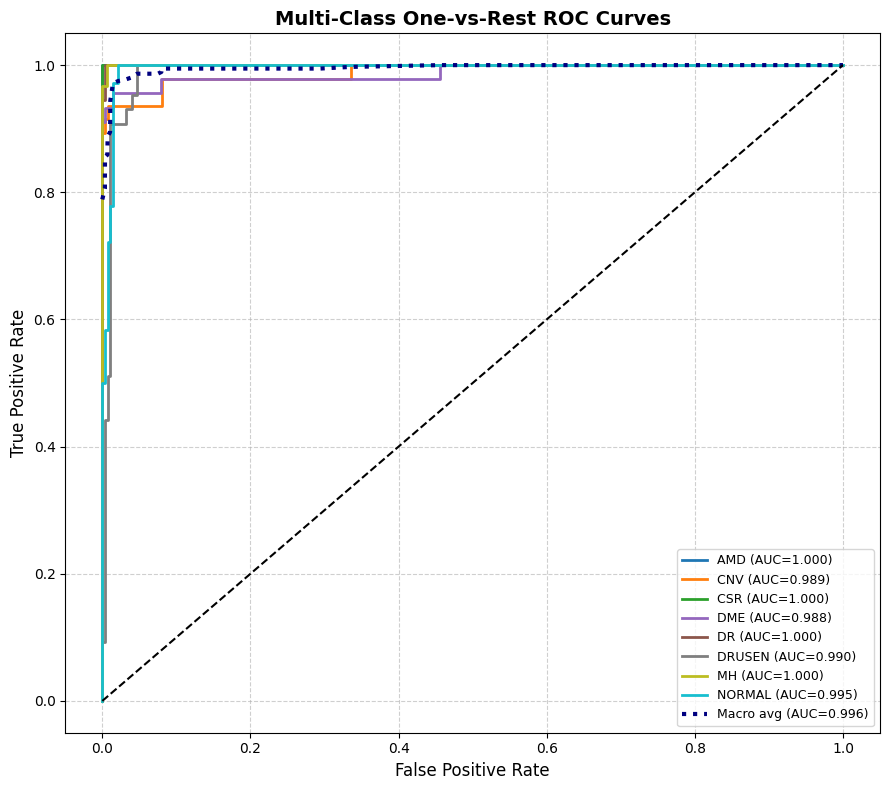

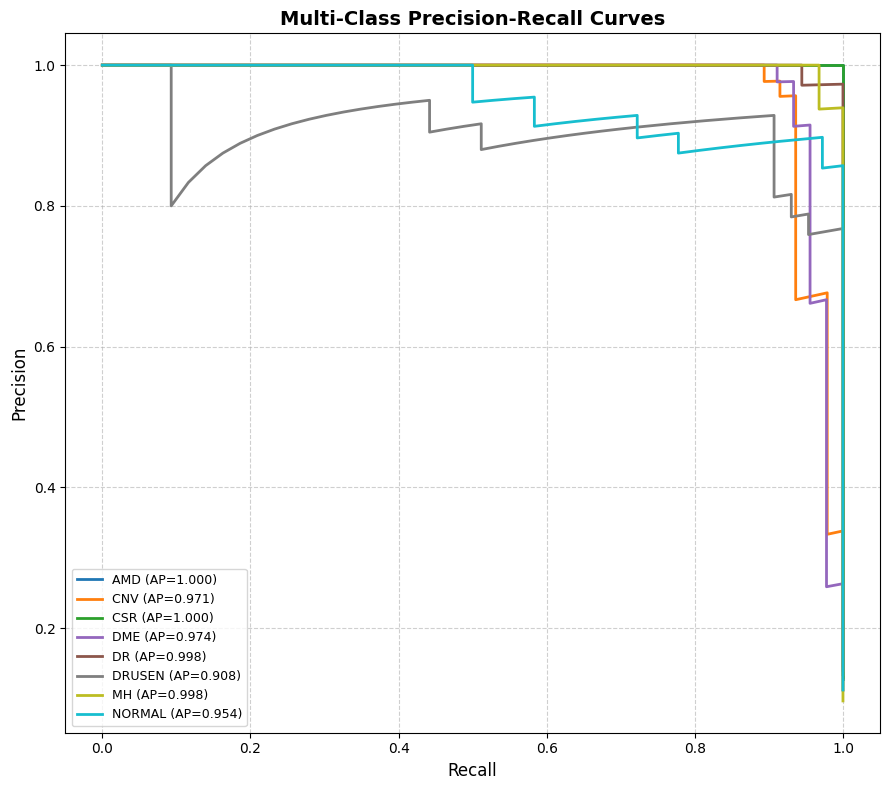

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
class_names = list(full_dataset.class_to_idx.keys())
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = sum(np.interp(all_fpr, fpr[i], tpr[i]) for i in range(num_classes)) / num_classes
fpr["macro"], tpr["macro"], roc_auc["macro"] = all_fpr, mean_tpr, auc(all_fpr, mean_tpr)

precision_dict, recall_dict, avg_precision = {}, {}, {}
for i in range(num_classes):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    avg_precision[i] = average_precision_score(y_true_bin[:, i], y_probs[:, i])

colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

fig, ax = plt.subplots(figsize=(9, 8))
for i, color in zip(range(num_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_names[i]} (AUC={roc_auc[i]:.3f})')
ax.plot(fpr["macro"], tpr["macro"], color='navy', linestyle=':', lw=3, label=f'Macro avg (AUC={roc_auc["macro"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_title('Multi-Class One-vs-Rest ROC Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc="lower right", fontsize=9, frameon=True); ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figure6_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 8))
for i, color in zip(range(num_classes), colors):
    ax.plot(recall_dict[i], precision_dict[i], color=color, lw=2, label=f'{class_names[i]} (AP={avg_precision[i]:.3f})')
ax.set_title('Multi-Class Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.legend(loc="lower left", fontsize=9, frameon=True); ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figure7_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

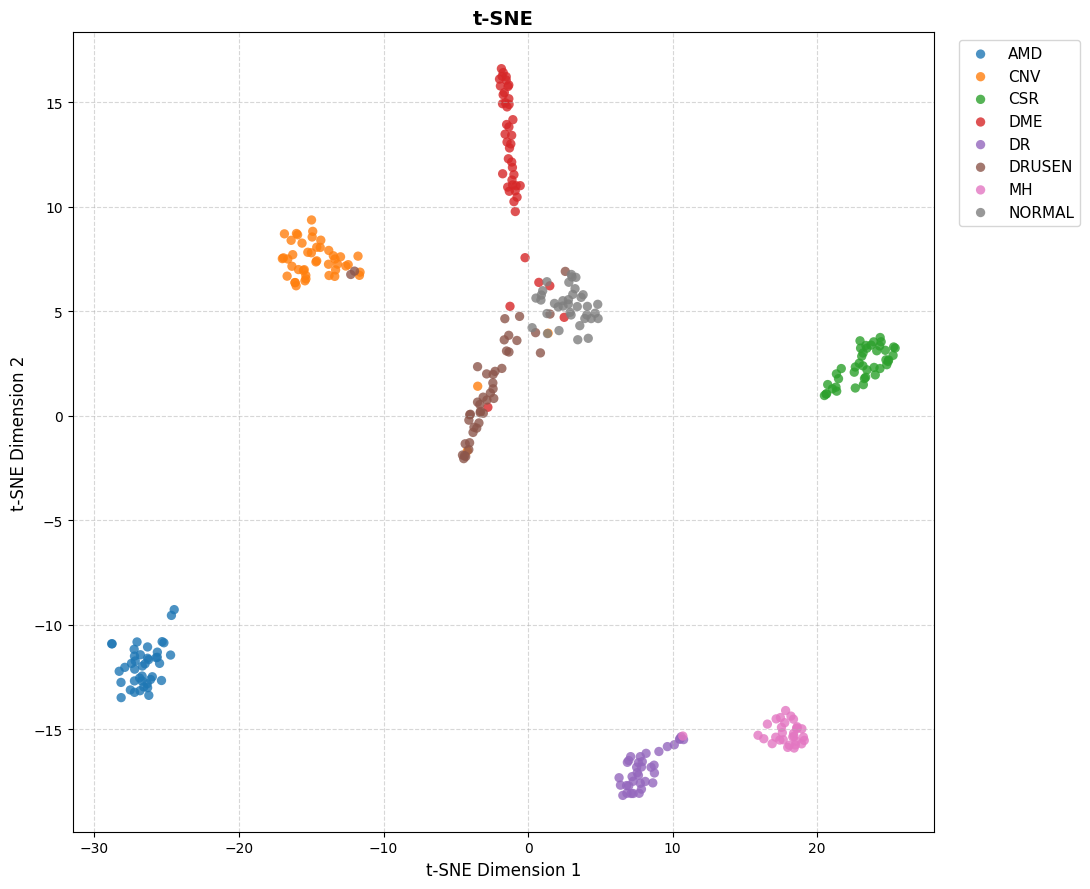

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns
latent_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(test_latents)
palette   = sns.color_palette("tab10", num_classes)
class_names = full_dataset.class_to_idx.keys()
fig, ax = plt.subplots(figsize=(11, 9))
for idx, cname in enumerate(class_names):
    mask = (y_true == idx)
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
               label=cname, color=palette[idx], alpha=0.8, edgecolors='none', s=45)
ax.set_title('t-SNE', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=12); ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figure10_tsne_latent_space.png', dpi=300, bbox_inches='tight')
plt.show()

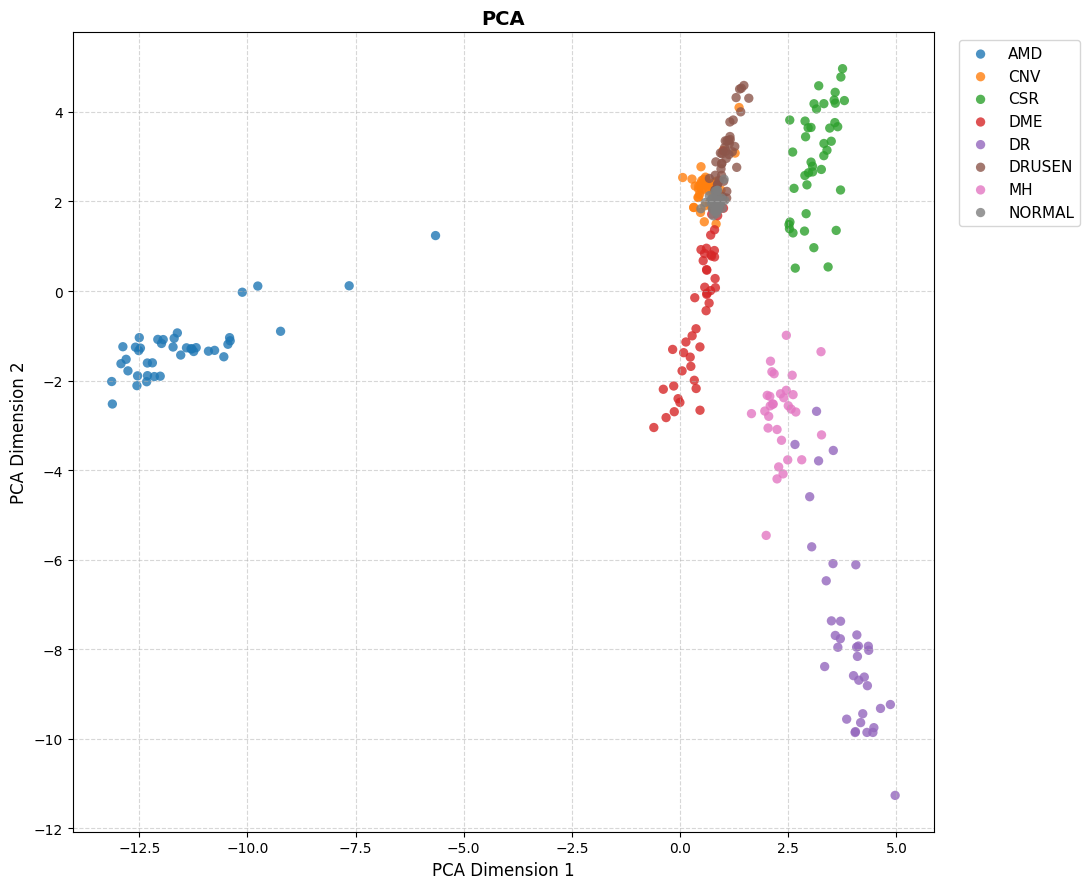

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
latent_2d = PCA(n_components=2).fit_transform(test_latents)
palette   = sns.color_palette("tab10", num_classes)
class_names = full_dataset.class_to_idx.keys()
fig, ax = plt.subplots(figsize=(11, 9))
for idx, cname in enumerate(class_names):
    mask = (y_true == idx)
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
               label=cname, color=palette[idx], alpha=0.8, edgecolors='none', s=45)
ax.set_title('PCA', fontsize=14, fontweight='bold')
ax.set_xlabel('PCA Dimension 1', fontsize=12); ax.set_ylabel('PCA Dimension 2', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figure10_PCA_latent_space.png', dpi=300, bbox_inches='tight')
plt.show()